# **Belgian GP 2026**
## Results and Lap Analysis

In [125]:
# Imports
import sys
import importlib
sys.path.append("../..")

import Sliplib.slipload as sl
import Sliplib.selection as slipclassify
import Sliplib.GridSum as grid_sum
import Sliplib.plotting as slplot
import Sliplib.battle_finder as battle
import configuration.writer as tpwrite

importlib.reload(slipclassify)
importlib.reload(grid_sum)
importlib.reload(battle)
importlib.reload(tpwrite)

<module 'configuration.writer' from '/mnt/Windows/Projects_S1/ProjectSlipstream/2026_Belgian_GP/notebooks/../../configuration/writer.py'>

In [99]:
# Load Session
session_Q = sl.load_gp(2025,"Belgian Grand Prix","Q")
session_Q.load()

core           INFO 	Loading data for Belgian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '16', '1', '23', '63', '22', '6', '30', '5', '31', '87', '10', '27', '55', '44', '43', '12', '14', '18']


### Result Inspection
Inspect Results of Qualifying Sessions

In [100]:
# Import Session Result
ses_res = session_Q.results
ses_res

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
4,4,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,1.0,,NaN,0 days 00:01:41.010000,0 days 00:01:40.715000,0 days 00:01:40.562000,NaT,,NaN,NaN
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,2.0,,NaN,0 days 00:01:41.201000,0 days 00:01:40.626000,0 days 00:01:40.647000,NaT,,NaN,NaN
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,3.0,,NaN,0 days 00:01:41.635000,0 days 00:01:41.084000,0 days 00:01:40.900000,NaT,,NaN,NaN
1,1,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,4781D7,red_bull,Max,Verstappen,Max Verstappen,...,4.0,,NaN,0 days 00:01:41.334000,0 days 00:01:40.951000,0 days 00:01:40.903000,NaT,,NaN,NaN
23,23,A ALBON,ALB,albon,Williams,1868DB,williams,Alexander,Albon,Alexander Albon,...,5.0,,NaN,0 days 00:01:41.772000,0 days 00:01:41.505000,0 days 00:01:41.201000,NaT,,NaN,NaN
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,6.0,,NaN,0 days 00:01:41.784000,0 days 00:01:41.254000,0 days 00:01:41.260000,NaT,,NaN,NaN
22,22,Y TSUNODA,TSU,tsunoda,Red Bull Racing,4781D7,red_bull,Yuki,Tsunoda,Yuki Tsunoda,...,7.0,,NaN,0 days 00:01:41.840000,0 days 00:01:41.245000,0 days 00:01:41.284000,NaT,,NaN,NaN
6,6,I HADJAR,HAD,hadjar,Racing Bulls,6C98FF,rb,Isack,Hadjar,Isack Hadjar,...,8.0,,NaN,0 days 00:01:41.572000,0 days 00:01:41.281000,0 days 00:01:41.310000,NaT,,NaN,NaN
30,30,L LAWSON,LAW,lawson,Racing Bulls,6C98FF,rb,Liam,Lawson,Liam Lawson,...,9.0,,NaN,0 days 00:01:41.748000,0 days 00:01:41.297000,0 days 00:01:41.328000,NaT,,NaN,NaN
5,5,G BORTOLETO,BOR,bortoleto,Kick Sauber,01C00E,sauber,Gabriel,Bortoleto,Gabriel Bortoleto,...,10.0,,NaN,0 days 00:01:41.908000,0 days 00:01:41.336000,0 days 00:01:42.387000,NaT,,NaN,NaN


In [101]:
ses_res.columns

Index(['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName',
       'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName',
       'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition',
       'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps'],
      dtype='object')

In [102]:
# Display Clean Result
Q_result = slipclassify.clean_result_Quali(ses_res)
Q_result

,Abbreviation,TeamName,Position
4,NOR,McLaren,1.0
81,PIA,McLaren,2.0
16,LEC,Ferrari,3.0
1,VER,Red Bull Racing,4.0
23,ALB,Williams,5.0
63,RUS,Mercedes,6.0
22,TSU,Red Bull Racing,7.0
6,HAD,Racing Bulls,8.0
30,LAW,Racing Bulls,9.0
5,BOR,Kick Sauber,10.0


In [103]:
# Export Results of Quali
Q_result.to_csv("../data/Quali_Result.csv")

### Time Analysis

In [104]:
# Load lap data
Q_lap = session_Q.laps
Q_lap

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:18:06.377000,NOR,4,NaT,1.0,1.0,0 days 00:15:43.335000,NaT,NaT,0 days 00:00:58.844000,...,False,McLaren,0 days 00:15:43.335000,2025-07-26 14:00:56.054,1,NaN,False,,False,False
1,0 days 00:19:48.453000,NOR,4,0 days 00:01:42.076000,2.0,1.0,NaT,NaT,0 days 00:00:30.336000,0 days 00:00:43.524000,...,False,McLaren,0 days 00:18:06.377000,2025-07-26 14:03:19.096,1,NaN,False,,False,True
2,0 days 00:21:52.143000,NOR,4,0 days 00:02:03.690000,3.0,1.0,NaT,0 days 00:21:48.355000,0 days 00:00:35.254000,0 days 00:00:51.890000,...,False,McLaren,0 days 00:19:48.453000,2025-07-26 14:05:01.172,1,NaN,False,,False,False
3,0 days 00:25:45.503000,NOR,4,NaT,4.0,2.0,0 days 00:23:34.839000,NaT,NaT,0 days 00:01:00.312000,...,True,McLaren,0 days 00:21:52.143000,2025-07-26 14:07:04.862,1,NaN,False,,False,False
4,0 days 00:27:26.513000,NOR,4,0 days 00:01:41.010000,5.0,2.0,NaT,NaT,0 days 00:00:30.223000,0 days 00:00:42.908000,...,True,McLaren,0 days 00:25:45.503000,2025-07-26 14:10:58.222,1,NaN,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287,0 days 00:23:48.211000,STR,18,0 days 00:01:42.683000,4.0,2.0,NaT,NaT,0 days 00:00:30.281000,0 days 00:00:44.093000,...,True,Aston Martin,0 days 00:22:05.528000,2025-07-26 14:07:18.247,1,NaN,False,,False,True
288,0 days 00:26:06.028000,STR,18,0 days 00:02:17.817000,5.0,2.0,NaT,0 days 00:26:02.205000,0 days 00:00:37.288000,0 days 00:00:58.270000,...,True,Aston Martin,0 days 00:23:48.211000,2025-07-26 14:09:00.930,1,NaN,False,,False,False
289,0 days 00:30:20.680000,STR,18,NaT,6.0,3.0,0 days 00:28:09.457000,NaT,NaT,0 days 00:00:59.736000,...,True,Aston Martin,0 days 00:26:06.028000,2025-07-26 14:11:18.747,1,NaN,False,,False,False
290,0 days 00:32:03.182000,STR,18,0 days 00:01:42.502000,7.0,3.0,NaT,NaT,0 days 00:00:30.222000,0 days 00:00:44.048000,...,True,Aston Martin,0 days 00:30:20.680000,2025-07-26 14:15:33.399,1,NaN,False,,False,True


In [105]:
# Fastest Lap
fastest_lap = Q_lap.pick_fastest()
fastest_lap

Time                      0 days 01:07:24.751000
Driver                                       NOR
DriverNumber                                   4
LapTime                   0 days 00:01:40.562000
LapNumber                                   16.0
Stint                                        5.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:30.005000
Sector2Time               0 days 00:00:42.579000
Sector3Time               0 days 00:00:27.978000
Sector1SessionTime        0 days 01:06:14.194000
Sector2SessionTime        0 days 01:06:56.773000
Sector3SessionTime        0 days 01:07:24.751000
SpeedI1                                    338.0
SpeedI2                                    217.0
SpeedFL                                    227.0
SpeedST                                    314.0
IsPersonalBest                              True
Compound                                    SOFT
TyreLife            

In [106]:
# Make it pretty
pretty_fast = slipclassify.analyse_fastest(fastest_lap)
pretty_fast

,Name,Value
0,Driver,NOR
1,LapNumber,16.0
2,LapTime,1:40.562
3,Stint,5.0
4,Compound,SOFT


In [107]:
# Get the total lap, stint made by each driver
lap_stint_summary = slipclassify.get_lap_stint(Q_lap)
lap_stint_summary

,Driver,TotalLaps,TotalStint
0,NOR,20,6
1,PIA,21,6
2,LEC,18,7
3,VER,15,5
4,ALB,20,7
5,RUS,18,6
6,TSU,17,6
7,HAD,19,7
8,LAW,20,7
9,BOR,18,6


In [108]:
# Extract the data
lap_stint_summary.to_csv("../data/Quali_Lap_stint.csv")

In [109]:
# Analyse Fresh Tyre Period
ft_period = slipclassify.get_fresh_tyre_period(Q_lap)
ft_period

,Driver,TyrePeriod
5,RUS,18
8,LAW,17
1,PIA,15
7,HAD,15
4,ALB,15
6,TSU,14
0,NOR,14
13,HUL,14
12,GAS,12
3,VER,12


In [110]:
# Extract Data
ft_period.to_csv("../data/Fresh_Tyre_Period.csv",index=False)

## Race Result Analysis

In [111]:
# Load Race Session
R_session = sl.load_gp(2025,"Belgian Grand Prix","R")
R_session.load()

core           INFO 	Loading data for Belgian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '81'
core        WARNING 	Fixed incorrect tyre stint information for driver '4'
core        WARNING 	Fixed incorrect tyre stint information for driver '16'
core        WARNING 	Fixed incorrect tyre stint information for driver '1'
core        WARNING 	Fixed incorrect tyre stint information for driver '63'
core        WARNING 	Fixed incorrect tyre stint information for driver '23'
core        WA

In [112]:
# Load Result
R_result = R_session.results
R_result

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,1.0,1,2.0,NaT,NaT,NaT,0 days 01:25:22.601000,Finished,25.0,44.0
4,4,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,2.0,2,1.0,NaT,NaT,NaT,0 days 00:00:03.415000,Finished,18.0,44.0
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,3.0,3,3.0,NaT,NaT,NaT,0 days 00:00:20.185000,Finished,15.0,44.0
1,1,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,4781D7,red_bull,Max,Verstappen,Max Verstappen,...,4.0,4,4.0,NaT,NaT,NaT,0 days 00:00:21.731000,Finished,12.0,44.0
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,5.0,5,6.0,NaT,NaT,NaT,0 days 00:00:34.863000,Finished,10.0,44.0
23,23,A ALBON,ALB,albon,Williams,1868DB,williams,Alexander,Albon,Alexander Albon,...,6.0,6,5.0,NaT,NaT,NaT,0 days 00:00:39.926000,Finished,8.0,44.0
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,7.0,7,18.0,NaT,NaT,NaT,0 days 00:00:40.679000,Finished,6.0,44.0
30,30,L LAWSON,LAW,lawson,Racing Bulls,6C98FF,rb,Liam,Lawson,Liam Lawson,...,8.0,8,9.0,NaT,NaT,NaT,0 days 00:00:52.033000,Finished,4.0,44.0
5,5,G BORTOLETO,BOR,bortoleto,Kick Sauber,01C00E,sauber,Gabriel,Bortoleto,Gabriel Bortoleto,...,9.0,9,10.0,NaT,NaT,NaT,0 days 00:00:56.434000,Finished,2.0,44.0
10,10,P GASLY,GAS,gasly,Alpine,00A1E8,alpine,Pierre,Gasly,Pierre Gasly,...,10.0,10,13.0,NaT,NaT,NaT,0 days 00:01:12.714000,Finished,1.0,44.0


In [113]:
clear_race = slipclassify.clean_result_race(R_result)
clear_race

,Abbreviation,TeamName,ClassifiedPosition
81,PIA,McLaren,1
4,NOR,McLaren,2
16,LEC,Ferrari,3
1,VER,Red Bull Racing,4
63,RUS,Mercedes,5
23,ALB,Williams,6
44,HAM,Ferrari,7
30,LAW,Racing Bulls,8
5,BOR,Kick Sauber,9
10,GAS,Alpine,10


In [114]:
# Extract Data
clear_race.to_csv("../data/Race_Result.csv",index=False)

### Insights:
- Max qualified P1 and finished P5
- Kimi got R
- Analysing the reason

In [115]:
messages = R_session.race_control_messages
messages

,Time,Category,Message,Status,Flag,Scope,Sector,RacingNumber,Lap
0,2025-07-27 12:19:00,Other,LOW GRIP CONDITIONS,None,None,None,NaN,None,1
1,2025-07-27 12:20:00,Flag,GREEN LIGHT - PIT EXIT OPEN,None,GREEN,Track,NaN,None,1
2,2025-07-27 12:22:08,Other,AWNINGS MAY BE USED,None,None,None,NaN,None,1
3,2025-07-27 12:26:06,Other,TRACK SURFACE SLIPPERY IN TRACK SECTOR 11,None,None,None,NaN,None,1
4,2025-07-27 12:26:17,Flag,CLEAR IN TRACK SECTOR 11,None,CLEAR,Sector,11.0,None,1
...,...,...,...,...,...,...,...,...,...
111,2025-07-27 15:46:05,Other,CAR 23 (ALB) TIME 1:47.252 DELETED - TRACK LIM...,None,None,None,NaN,None,44
112,2025-07-27 15:46:41,Other,CAR 22 (TSU) TIME 1:48.375 DELETED - TRACK LIM...,None,None,None,NaN,None,44
113,2025-07-27 15:48:29,Other,ALL PASS HOLDERS MAY ACCESS THE PIT LANE,None,None,None,NaN,None,44
114,2025-07-27 15:48:59,Flag,DOUBLE YELLOW IN TRACK SECTOR 10,None,DOUBLE YELLOW,Sector,10.0,None,44


In [116]:
# Check Track Status
track_history = slipclassify.analyse_track_History(messages)
track_history

,Flags,Occurence
0,None,0
1,GREEN,2
2,CLEAR,40
3,RED,1
4,DOUBLE YELLOW,22
5,YELLOW,5
6,BLACK AND WHITE,1
7,BLUE,4
8,CHEQUERED,1


### Insights
- No Red Flag in the session
- So, no serious incidents
- But, minor incidents occured

In [117]:
# Position Gain Calculation of Drivers
ret_1 = grid_sum.calc_pos_gain(R_result)
ret_1

,Driver,PositionGain,Status
0,HAM,11,Finished
1,ANT,3,Finished
2,GAS,3,Finished
3,ALO,3,Finished
4,HUL,2,Finished
5,STR,2,Finished
6,BOR,1,Finished
7,PIA,1,Finished
8,LAW,1,Finished
9,BEA,1,Finished


## Race Lap Analysis
From the above analysis, the Best Perfomance Drivers to examine are:
- Nico Hulkenberg made an awesome Perfomance by 16 Poisition Gain
- Lance Stroll has climbed up 10 positions
- Lando Norris 2 position gain
- Oscar Piastri maintained the same
- Charles Leclerc made very poor perfomance by climbing down by 8 positions

In [118]:
R_Laps = R_session.laps
R_Laps.head(5)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 02:17:37.928000,PIA,81,0 days 00:03:05.558000,1.0,1.0,0 days 02:14:45.252000,NaT,NaT,0 days 00:01:22.953000,...,True,McLaren,0 days 02:14:32.096000,2025-07-27 14:20:00.066,14,2.0,False,,False,False
1,0 days 02:20:32.417000,PIA,81,NaT,2.0,1.0,NaT,NaT,0 days 00:00:46.259000,0 days 00:01:21.693000,...,True,McLaren,0 days 02:17:37.928000,2025-07-27 14:23:05.898,4,2.0,False,,False,False
2,0 days 02:23:23.986000,PIA,81,NaT,3.0,1.0,NaT,NaT,0 days 00:00:45.865000,0 days 00:01:20.585000,...,True,McLaren,0 days 02:20:32.417000,2025-07-27 14:26:00.387,4,2.0,False,,False,False
3,0 days 02:26:25.966000,PIA,81,NaT,4.0,1.0,NaT,NaT,0 days 00:00:45.056000,0 days 00:01:25.005000,...,True,McLaren,0 days 02:23:23.986000,2025-07-27 14:28:51.956,41,2.0,False,,False,False
4,0 days 02:28:25.058000,PIA,81,0 days 00:01:59.092000,5.0,1.0,NaT,NaT,0 days 00:00:32.950000,0 days 00:00:54.450000,...,True,McLaren,0 days 02:26:25.966000,2025-07-27 14:31:53.936,1,1.0,False,,False,True


In [126]:
# Analyse the top 4 battle
contenders, rivals = battle.find_top_battles(R_Laps,n=6)

In [127]:
# Write Contenders to file
tpwrite.write_contenders(contenders,rivals)

Configuration Written!


In [ ]:
# Import Drivers
hul,stro,nor,pia,lec,ham,ver = slipclassify.pick_athletes(R_Laps,["HUL","STR","NOR","PIA","LEC","HAM","VER"])

# Test
lec.head(10)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
88,0 days 02:17:40.888000,LEC,16,0 days 00:03:08.456000,1.0,1.0,0 days 02:14:48.268000,NaT,NaT,0 days 00:01:22.600000,...,True,Ferrari,0 days 02:14:32.096000,2025-07-27 14:20:00.066,14,3.0,False,,False,False
89,0 days 02:20:34.519000,LEC,16,NaT,2.0,1.0,NaT,NaT,0 days 00:00:46.016000,0 days 00:01:20,...,True,Ferrari,0 days 02:17:40.888000,2025-07-27 14:23:08.858,4,3.0,False,,False,False
90,0 days 02:23:25.835000,LEC,16,NaT,3.0,1.0,NaT,NaT,0 days 00:00:45.364000,0 days 00:01:20.848000,...,True,Ferrari,0 days 02:20:34.519000,2025-07-27 14:26:02.489,4,3.0,False,,False,False
91,0 days 02:26:26.594000,LEC,16,NaT,4.0,1.0,NaT,NaT,0 days 00:00:44.829000,0 days 00:01:24.132000,...,True,Ferrari,0 days 02:23:25.835000,2025-07-27 14:28:53.805,41,3.0,False,,False,False
92,0 days 02:28:27.057000,LEC,16,0 days 00:02:00.463000,5.0,1.0,NaT,NaT,0 days 00:00:32.971000,0 days 00:00:56.048000,...,True,Ferrari,0 days 02:26:26.594000,2025-07-27 14:31:54.564,1,3.0,False,,False,True
93,0 days 02:30:27.199000,LEC,16,0 days 00:02:00.142000,6.0,1.0,NaT,NaT,0 days 00:00:32.732000,0 days 00:00:55.815000,...,True,Ferrari,0 days 02:28:27.057000,2025-07-27 14:33:55.027,1,3.0,False,,False,True
94,0 days 02:32:27.753000,LEC,16,0 days 00:02:00.554000,7.0,1.0,NaT,NaT,0 days 00:00:33.067000,0 days 00:00:55.695000,...,True,Ferrari,0 days 02:30:27.199000,2025-07-27 14:35:55.169,1,3.0,False,,False,True
95,0 days 02:34:29.573000,LEC,16,0 days 00:02:01.820000,8.0,1.0,NaT,NaT,0 days 00:00:33.191000,0 days 00:00:56.337000,...,True,Ferrari,0 days 02:32:27.753000,2025-07-27 14:37:55.723,1,3.0,False,,False,True
96,0 days 02:36:33.283000,LEC,16,0 days 00:02:03.710000,9.0,1.0,NaT,NaT,0 days 00:00:33.632000,0 days 00:00:57.514000,...,True,Ferrari,0 days 02:34:29.573000,2025-07-27 14:39:57.543,1,3.0,False,,False,True
97,0 days 02:38:37.491000,LEC,16,0 days 00:02:04.208000,10.0,1.0,NaT,NaT,0 days 00:00:33.674000,0 days 00:00:58.244000,...,True,Ferrari,0 days 02:36:33.283000,2025-07-27 14:42:01.253,1,3.0,False,,False,True


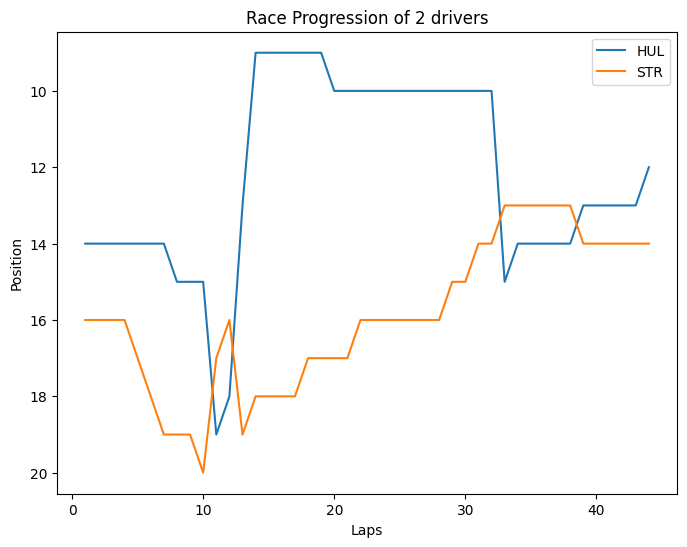

In [ ]:
# Plot showing the 2 Contenders
slplot.plot_race_progression([hul,stro])

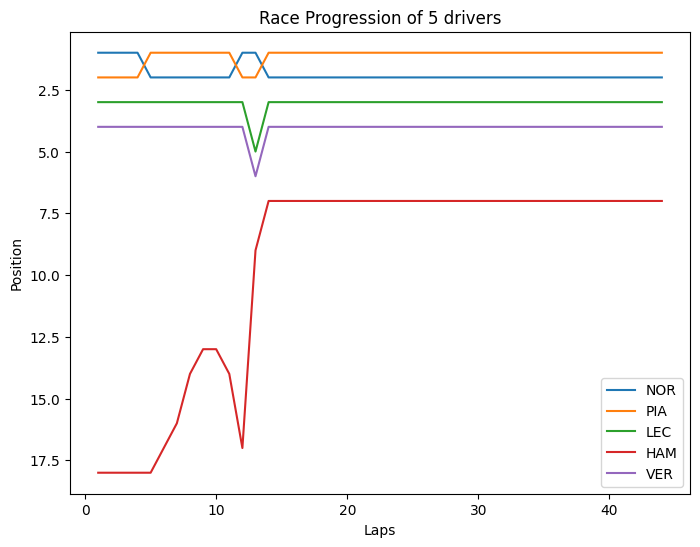

In [ ]:
# Plots showing The Top grid
slplot.plot_race_progression([nor,pia,lec,ham,ver])